# Analyze Energy Ratios during Baseline Operation

In this notebook, we will demonstrate how to compute and plot the energy ratio between test and reference turbines as a function of wind direction. We'll focus on baseline operation for this example (i.e., without wake steering). The energy ratios can be used to evaluate wake losses experienced by different turbines.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from flasc.analysis import energy_ratio as er
from flasc.analysis.analysis_input import AnalysisInput
from flasc.data_processing import dataframe_manipulations as dfm
from flasc.data_processing import time_operations as tops
from flasc.utilities import floris_tools as ftools
from flasc.utilities.utilities_examples import load_floris_smarteole as load_floris

In [2]:
# Suppress warnings
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Introduce helper functions for calculating errors and generating plots/tables
def err(old_val, new_val):
    return 100.0 * (new_val-old_val) / old_val

# Introduce helper functions for calculating errors and generating plots/tables
def wake_loss(aep_waked, aep_unwaked):
    return 100.0 * (aep_unwaked-aep_waked) / aep_unwaked

def print_pretty_table(table_dict, title):
    # Format title to be centered above the table, and print table in pretty format
    df_table = pd.DataFrame(table_dict)
    mrkdwn = df_table.to_markdown(headers='keys', tablefmt='psql', index=False, floatfmt=".2f")
    spc = int(np.floor(len(mrkdwn.split("\n")[0]) / 2 - len(title) / 2))
    mrkdwn = (" " * spc + title + "\n") + mrkdwn
    return print(mrkdwn)

# Step 0: Load processed data

Load the processed SCADA data with power curve filtering and northing calibration applied and inspect

In [4]:
def load_data():
    root_path = Path.cwd()
    f = root_path / "postprocessed" / "df_scada_data_60s_filtered_and_northing_calibrated.pkl"
    df_scada = pd.read_pickle(f)

    return df_scada


df_scada = load_data()
df_scada.describe()

,time,pow_000,pow_001,pow_002,pow_003,pow_004,pow_005,pow_006,ws_000,ws_001,...,wd_004,wd_005,wd_006,wind_vane_005,target_yaw_offset_005,wd_smarteole,ws_smarteole,pow_ref_smarteole,ti,wd
count,134661,107963.000000,104981.000000,91702.000000,100774.000000,105342.000000,99677.000000,106162.000000,107963.000000,104981.000000,...,105342.000000,99677.000000,106162.000000,99677.000000,99677.000000,131704.000000,131699.000000,130266.000000,1.346610e+05,115725.000000
mean,2020-04-04 18:49:02.648873472,777.708679,722.314758,788.448669,650.102112,714.342102,707.234131,734.999878,7.992576,7.441976,...,147.802322,152.649872,145.970215,0.825125,0.786913,147.975891,7.286752,639.086670,1.100000e-01,147.127971
min,2020-02-17 16:30:00,0.001000,0.003000,0.002000,0.009000,0.007000,0.032000,0.000000,1.483000,2.746000,...,0.022003,0.009750,0.191750,-43.056999,-0.000000,0.005929,0.101000,-45.498859,1.100000e-01,0.035299
25%,2020-03-12 01:51:00,235.326004,214.001999,246.753754,192.749237,205.838989,173.522003,219.312500,6.128000,5.577000,...,50.160999,52.731747,49.358002,-5.912000,0.000000,47.813652,5.121595,98.970131,1.100000e-01,47.609299
50%,2020-04-04 10:58:00,571.359985,528.625000,593.072998,467.079498,504.357483,504.005005,540.981506,7.448000,7.027000,...,126.497002,163.868759,134.247757,0.187000,0.000000,138.522034,7.423318,422.463989,1.100000e-01,136.630460
75%,2020-04-27 20:03:00,1238.735962,1119.993042,1244.010986,997.394531,1098.766724,1124.659058,1134.179199,9.587500,8.942000,...,235.623001,235.056763,232.824249,6.927000,0.000000,235.295410,9.361652,1049.996338,1.100000e-01,233.829382
max,2020-05-24 23:59:00,2064.696045,2065.387939,2051.489990,2062.987061,2064.689941,2078.750977,2076.895996,20.851999,21.240999,...,359.997009,359.980743,359.988770,59.181999,20.000000,359.991791,20.422459,2147.802246,1.100000e-01,359.957790
std,NaN,639.332153,609.761963,636.423706,560.708984,617.146301,622.352234,618.290527,2.548205,2.501244,...,99.606598,97.270058,97.408218,10.048730,3.216291,101.749588,3.104111,629.421570,1.387784e-17,100.096957


In [5]:
df_scada.columns

Index(['time', 'pow_000', 'pow_001', 'pow_002', 'pow_003', 'pow_004',
       'pow_005', 'pow_006', 'ws_000', 'ws_001', 'ws_002', 'ws_003', 'ws_004',
       'ws_005', 'ws_006', 'wd_000', 'wd_001', 'wd_002', 'wd_003', 'wd_004',
       'wd_005', 'wd_006', 'is_operation_normal_000',
       'is_operation_normal_001', 'is_operation_normal_002',
       'is_operation_normal_003', 'is_operation_normal_004',
       'is_operation_normal_005', 'is_operation_normal_006', 'wind_vane_005',
       'target_yaw_offset_005', 'control_mode', 'wd_smarteole', 'ws_smarteole',
       'pow_ref_smarteole', 'ti', 'wd'],
      dtype='object')

# Step 1: Limit to baseline data

The SCADA data set contains alternating 1-hour periods with baseline or wake steering control. For these examples, we'll limit the data to baseline operation. 

In [6]:
df_scada = df_scada[df_scada.control_mode == "baseline"].reset_index(drop=True)

# Step 2: Compute reference wind direction, wind speed, and power variables

The energy ratio class as presently implemented requires explicit identification of the dataframe of columns "wd," "ws," and "pow_ref." We'll use the FLORIS model to establish which turbines are unwaked for each wind direction to compute the reference variables.

In [7]:
# Load FLORIS model of site
fm, turbine_weights = load_floris()

# Use FLORIS to identify upstream / unwaked turbines for
# each direction
df_upstream = ftools.get_upstream_turbs_floris(fm)
df_upstream.head()

,wd_min,wd_max,turbines
0,0.0,25.0,[0]
1,25.0,28.0,"[0, 2]"
2,28.0,31.0,"[0, 2, 6]"
3,31.0,31.3,"[0, 2, 3, 6]"
4,31.3,31.5,"[0, 2, 3, 4, 6]"


In [8]:
# Use flasc tools to establish reference wind speeds and directions

# Helper variables
n_turbs = dfm.get_num_turbines(df_scada)
pow_cols = [f"pow_{ti:03d}" for ti in range(n_turbs)]

# Since will be interested in looking at impacts on SMV5/[4], exclude
# it from each calculation

# Set the wind direction as the average of all turbine averages
df_scada = dfm.set_wd_by_turbines(df_scada, [0, 1, 2, 3, 5, 6])

# Set the wind speed to be the average of all upstream turbines
# (turbines not in a wake in a given direction)
# Except for SMV5
df_scada = dfm.set_ws_by_upstream_turbines(df_scada, df_upstream, exclude_turbs=[4])

# Set the reference power to the average of all upstream turbines
# Except for SMV5
df_scada = dfm.set_pow_ref_by_upstream_turbines(df_scada, df_upstream, exclude_turbs=[4])

# Determine number of turbines available at any given time
df_scada["n_turbs_available"] = (~df_scada[pow_cols].isna()).sum(axis=1)
print(df_scada)

FlascDataFrame in FLASC format
                     time      pow_000      pow_001      pow_002     pow_003  \
0     2020-02-17 16:30:00  2023.746948  2045.376953  2031.724976         NaN   
1     2020-02-17 16:31:00  1959.036011  2050.572998  2034.890991         NaN   
2     2020-02-17 16:32:00  2053.658936  2032.191040  2011.870972         NaN   
3     2020-02-17 16:33:00  2044.296997  2060.478027  1995.057983         NaN   
4     2020-02-17 16:34:00  2058.281006  2042.703003  2031.723999         NaN   
...                   ...          ...          ...          ...         ...   
81949 2020-05-24 22:56:00   179.934006   157.003998   192.214996  188.412994   
81950 2020-05-24 22:57:00   181.414993   176.386002   191.845993  198.539993   
81951 2020-05-24 22:58:00   187.748001   181.809006   183.802994  179.539001   
81952 2020-05-24 22:59:00   175.552002   176.250000   183.923004  152.393005   
81953 2020-05-24 23:00:00   169.324997   179.944000   173.608002  136.597000   

        

# Step 3: Compute and Plot Energy Ratio for Turbine 004

Compare the energy ratio for turbine 004 based on the SCADA data to the equivalent predicted energy ratios from each FLORIS model using our precomputed FLORIS results. Turbine 004 is the downstream waked turbine that benefits from wake steering in the SMARTEOLE wake steering field experiment.

The energy ratios computed here simply represent the ratio between the energy produced by the test turbines and the energy computed using the reference power variable, "pow_ref," as a function of wind direction.

In [9]:
# Grab a FLORIS solution and turn it into a timeseries
wake_model = "cc"
fn = Path.cwd() / "precalculated_floris_solutions" / "df_fi_approx_{:s}.ftr".format(wake_model)
if fn.is_file():
    df_fm_approx = pd.read_feather(fn)
else:
    raise UserWarning(
        "Please run '01_precalculate_floris_solutions.ipynb' "
        "for the appropriate wake models first."
    )

df_floris_timeseries = ftools.interpolate_floris_from_df_approx(
    df=df_scada, df_approx=df_fm_approx, method="linear", verbose=True
)
print(df_floris_timeseries)

2025-11-06 08:34:37 Identified the following grid type: 3d.
2025-11-06 08:34:37 Warning: the values in df[ws] exceed the range in the precalculated solutions df_fi_approx[ws].
2025-11-06 08:34:37    minimum/maximum value in df:        (0.250, 19.544)
2025-11-06 08:34:37    minimum/maximum value in df:        (0.250, 19.544)
2025-11-06 08:34:37    minimum/maximum value in df_approx: (1.000, 30.000)
2025-11-06 08:34:37 Mapping the precalculated solutions from FLORIS to the dataframe...
2025-11-06 08:34:37   Creating a gridded interpolant with interpolation method 'linear'.
2025-11-06 08:34:37      Interpolating pow for all turbines...
2025-11-06 08:34:37 Finished interpolation in 0.083 seconds.


FlascDataFrame in FLASC format
               wd         ws    ti                time       pow_000  \
0      251.011217  12.552600  0.11 2020-02-17 16:30:00  1.957574e+06   
1      251.005696  12.692800  0.11 2020-02-17 16:31:00  1.970251e+06   
2      253.473037  12.888800  0.11 2020-02-17 16:32:00  1.987973e+06   
3      251.104001  13.468800  0.11 2020-02-17 16:33:00  2.017250e+06   
4      255.679234  13.029600  0.11 2020-02-17 16:34:00  1.999241e+06   
...           ...        ...   ...                 ...           ...   
81949  307.044361   5.380833  0.11 2020-05-24 22:56:00  2.169107e+05   
81950  307.204886   5.371500  0.11 2020-05-24 22:57:00  2.154713e+05   
81951  308.822990   5.314167  0.11 2020-05-24 22:58:00  2.066296e+05   
81952  311.222440   5.259000  0.11 2020-05-24 22:59:00  1.981221e+05   
81953  311.095105   5.243167  0.11 2020-05-24 23:00:00  1.956804e+05   

            pow_001       pow_002        pow_003       pow_004       pow_005  \
0      1.957574e+06  1.9

In [ ]:
# Define function to produce error scores
def compare_absolute_aep_and_relative_wake_loss(df_scada, df_les):
    # Make local copy of df_les that we can manipulate
    df_scada = df_scada.copy()
    df_les = df_les.copy()

    # Specify a unit conversion
    unit_conversion = 1.0e-3 / (np.timedelta64(3600, 's') / np.nanmedian(df_scada["time"].diff()))  # From sum of samples to MWh

    # First ensure consistent NaN mapping between LES and SCADA
    n_turbs = dfm.get_num_turbines(df_scada)
    for ti in range(n_turbs):
        ids_nan, _ = np.where(
            df_scada[f"pow_{ti:03d}"].isna() | df_les[f"pow_{ti:03d}"].isna()
        )
        df_les.loc[ids_nan, f"pow_{ti:03d}"] = None
        df_scada.loc[ids_nan, f"pow_{ti:03d}"] = None

    # # Assert NaNs are identical between dataframes
    # n_scada = df_scada[pow_cols].isna().sum().sum()
    # n_les = df_les[pow_cols].isna().sum().sum()
    # print(f"NaNs in df_scada power columns: {n_scada}")
    # print(f"NaNs in df_les power columns: {n_les}")

    # Specify upstream power in the exact same way as with the SCADA data
    df_les = dfm.set_pow_ref_by_upstream_turbines(df_les, df_upstream, exclude_turbs=[4])

    # Determine number of turbines available at any given time, similar to SCADA
    df_les["n_turbs_available"] = (~df_les[pow_cols].isna()).sum(axis=1)
    # print(df_les)

    # # Assert that number of turbines available at each timestamp is identical between SCADA and LES simulation
    # all(df_les["n_turbs_available"] == df_scada["n_turbs_available"])

    #######################################################################################################################
    ################## Compare absolute AEP directly between SCADA and simulated data (LES) ###############################
    #######################################################################################################################

    # Absolute AEP for the entire farm and per turbine
    aep_turbine_scada = [df_scada[pc].sum() * unit_conversion for pc in pow_cols]
    aep_turbine_les = [df_les[pc].sum() * unit_conversion for pc in pow_cols]
    aep_farm_scada = np.sum(aep_turbine_scada)
    aep_farm_les = np.sum(aep_turbine_les)

    table_absolute_aep_dict = {
        "Selection": ["Entire farm"] + [f"Turbine {ti:02d}" for ti in range(n_turbs)],
        "SCADA (MWh)": [aep_farm_scada] + aep_turbine_scada,
        "LES (MWh)": [aep_farm_les] + aep_turbine_les,
        "Error (%)": [err(aep_farm_scada, aep_farm_les)] + [err(x, y) for x, y in zip(aep_turbine_scada, aep_turbine_les)]
    }
    print_pretty_table(table_absolute_aep_dict, title="Absolute cumulative energy (MWh)")
    print("\n")

    #######################################################################################################################
    ################ Now we do the same exercise, but with wake loss rather than absolute AEP #############################
    #######################################################################################################################

    # Compare AEP wake loss relative to most upstream turbines
    aep_turbine_scada_waked = np.array([None for _ in range(n_turbs)], dtype=float)
    aep_turbine_scada_unwaked = np.array([None for _ in range(n_turbs)], dtype=float)
    aep_turbine_les_waked = np.array([None for _ in range(n_turbs)], dtype=float)
    aep_turbine_les_unwaked = np.array([None for _ in range(n_turbs)], dtype=float)

    for ti in range(n_turbs):
        # First SCADA
        p_test = np.array(df_scada[f"pow_{ti:03d}"], dtype=float, copy=True)
        p_ref = np.array(df_scada["pow_ref"], dtype=float, copy=True)
        ids_non_nan = (~np.isnan(p_test)) & (~np.isnan(p_ref))
        aep_turbine_scada_unwaked[ti] = np.sum(p_ref[ids_non_nan]) * unit_conversion
        aep_turbine_scada_waked[ti] = np.sum(p_test[ids_non_nan]) * unit_conversion

        # Now LES
        p_test = np.array(df_les[f"pow_{ti:03d}"], dtype=float, copy=True)
        p_ref = np.array(df_les["pow_ref"], dtype=float, copy=True)
        ids_non_nan = (~np.isnan(p_test)) & (~np.isnan(p_ref))
        aep_turbine_les_unwaked[ti] = np.sum(p_ref[ids_non_nan]) * unit_conversion
        aep_turbine_les_waked[ti] = np.sum(p_test[ids_non_nan]) * unit_conversion

    aep_farm_scada_waked = np.sum(aep_turbine_scada_waked)
    aep_farm_scada_unwaked = np.sum(aep_turbine_scada_unwaked)
    aep_farm_les_waked = np.sum(aep_turbine_les_waked)
    aep_farm_les_unwaked = np.sum(aep_turbine_les_unwaked)

    # Derive wake loss percentages and errors, and print as a pretty table
    wake_losses_scada = np.hstack(
        [
            wake_loss(aep_farm_scada_waked, aep_farm_scada_unwaked),
            wake_loss(aep_turbine_scada_waked, aep_turbine_scada_unwaked)
        ]
    )
    wake_losses_les = np.hstack(
        [
            wake_loss(aep_farm_les_waked, aep_farm_les_unwaked),
            wake_loss(aep_turbine_les_waked, aep_turbine_les_unwaked)
        ]
    )

    table_wakeloss_aep_dict = {
        "Selection": ["Entire farm"] + [f"Turbine {ti:02d}" for ti in range(n_turbs)],
        "SCADA (%)": wake_losses_scada,
        "LES (%)": wake_losses_les,
        "Error (p.p.)": wake_losses_les - wake_losses_scada
    }
    print_pretty_table(table_wakeloss_aep_dict, title="Cumulative energy wake loss (%)")

    return table_absolute_aep_dict, table_wakeloss_aep_dict

In [21]:
########################################################################################################################################
###### Load LES timeseries in preparation for validation against SCADA. We will try various validation metrics and approaches... #######
########################################################################################################################################

# Grab the raw LES timeseries
df_les_timeseries_raw = pd.read_csv("data/SMARTEOLE-LES-simulation-data/les_timeseries.csv")
df_les_timeseries_raw["time"] = pd.to_datetime(df_les_timeseries_raw["time"])

# Fix scaling in LES from [W] to [kW]
df_les_timeseries_raw[pow_cols] *= 1.0e-3

# Assign freestream ambient conditions by the metmast
df_les_timeseries_raw = df_les_timeseries_raw.rename(columns={"wd_metmast": "wd", "ws_metmast": "ws", "ti_metmast": "ti"})

# Map raw LES directly to the SCADA timeseries using linear interpolation
df_les_raw_resampled = tops.df_resample_by_interpolation(
    df=df_les_timeseries_raw,
    time_array=pd.to_datetime(df_scada["time"]),
    circular_cols=["wd_metmast"],
)

2025-11-06 08:39:01   Resampling column 'wd' with median timestep 60.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2025-11-06 08:39:01   Resampling column 'ws' with median timestep 60.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2025-11-06 08:39:01   Resampling column 'ti' with median timestep 60.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2025-11-06 08:39:02   Resampling column 'pow_000' with median timestep 60.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2025-11-06 08:39:02   Resampling column 'pow_001' with median timestep 60.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2025-11-06 08:39:02   Resampling column 'pow_002' with median timestep 60.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=F

In [22]:
########################################################################################################################################
## Option for validation 1: compare the two timeseries directly, assuming (hoping) that LES predicted the inflow conditions accurately.
## For this, we must ensure the NaNs in the SCADA also appear as NaNs in the LES timeseries. Assuming the same timezone format...
########################################################################################################################################

# Now being on the same timeseries, map NaNs from SCADA to LES
df_les = df_les_raw_resampled.copy()

# Perform comparison using this LES dataframe
table_absolute_aep_dict, table_wakeloss_aep_dict = compare_absolute_aep_and_relative_wake_loss(df_scada, df_les)

             Absolute cumulative energy (MWh)
+-------------+---------------+-------------+-------------+
| Selection   |   SCADA (MWh) |   LES (MWh) |   Error (%) |
|-------------+---------------+-------------+-------------|
| Entire farm |       4520.69 |     4446.18 |       -1.65 |
| Turbine 00  |        731.14 |      692.91 |       -5.23 |
| Turbine 01  |        653.47 |      627.12 |       -4.03 |
| Turbine 02  |        631.30 |      607.47 |       -3.78 |
| Turbine 03  |        562.20 |      555.17 |       -1.25 |
| Turbine 04  |        655.00 |      649.53 |       -0.84 |
| Turbine 05  |        606.47 |      602.00 |       -0.74 |
| Turbine 06  |        681.11 |      711.97 |        4.53 |
+-------------+---------------+-------------+-------------+


             Cumulative energy wake loss (%)
+-------------+-------------+-----------+----------------+
| Selection   |   SCADA (%) |   LES (%) |   Error (p.p.) |
|-------------+-------------+-----------+----------------|
| Entire f

No circular columns specified. Automatically identified: [].
Applying regular averaging on entire dataframe (14 columns).
Applying circular averaging on 0 columns.
Flagged an additional 82 table entries as NaN because their sample pool is smaller than 3 (N_min).


2025-11-06 08:39:22 Identified the following grid type: 2d.
2025-11-06 08:39:22 Warning: the values in df[wd] exceed the range in the precalculated solutions df_fi_approx[wd].
2025-11-06 08:39:22    minimum/maximum value in df:        (0.021, 359.941)
2025-11-06 08:39:22    minimum/maximum value in df:        (0.021, 359.941)
2025-11-06 08:39:22    minimum/maximum value in df_approx: (0.000, 355.000)
2025-11-06 08:39:22 Warning: the values in df[ws] exceed the range in the precalculated solutions df_fi_approx[ws].
2025-11-06 08:39:22    minimum/maximum value in df:        (0.250, 19.544)
2025-11-06 08:39:22    minimum/maximum value in df:        (0.250, 19.544)
2025-11-06 08:39:22    minimum/maximum value in df_approx: (4.000, 20.000)
2025-11-06 08:39:22 Warning: the values in df[ti] exceed the range in the precalculated solutions df_fi_approx[ti].
2025-11-06 08:39:22    minimum/maximum value in df:        (0.110, 0.110)
2025-11-06 08:39:22    minimum/maximum value in df:        (0.110

Approximate table contains 742 valid entries (60.62%) and 482 invalid entries (39.38%).
             Absolute cumulative energy (MWh)
+-------------+---------------+-------------+-------------+
| Selection   |   SCADA (MWh) |   LES (MWh) |   Error (%) |
|-------------+---------------+-------------+-------------|
| Entire farm |       4520.69 |     4723.36 |        4.48 |
| Turbine 00  |        731.14 |      736.14 |        0.68 |
| Turbine 01  |        653.47 |      672.57 |        2.92 |
| Turbine 02  |        631.30 |      634.58 |        0.52 |
| Turbine 03  |        562.20 |      604.95 |        7.60 |
| Turbine 04  |        655.00 |      686.53 |        4.81 |
| Turbine 05  |        606.47 |      637.06 |        5.04 |
| Turbine 06  |        681.11 |      751.53 |       10.34 |
+-------------+---------------+-------------+-------------+


             Cumulative energy wake loss (%)
+-------------+-------------+-----------+----------------+
| Selection   |   SCADA (%) |   LES (%) 

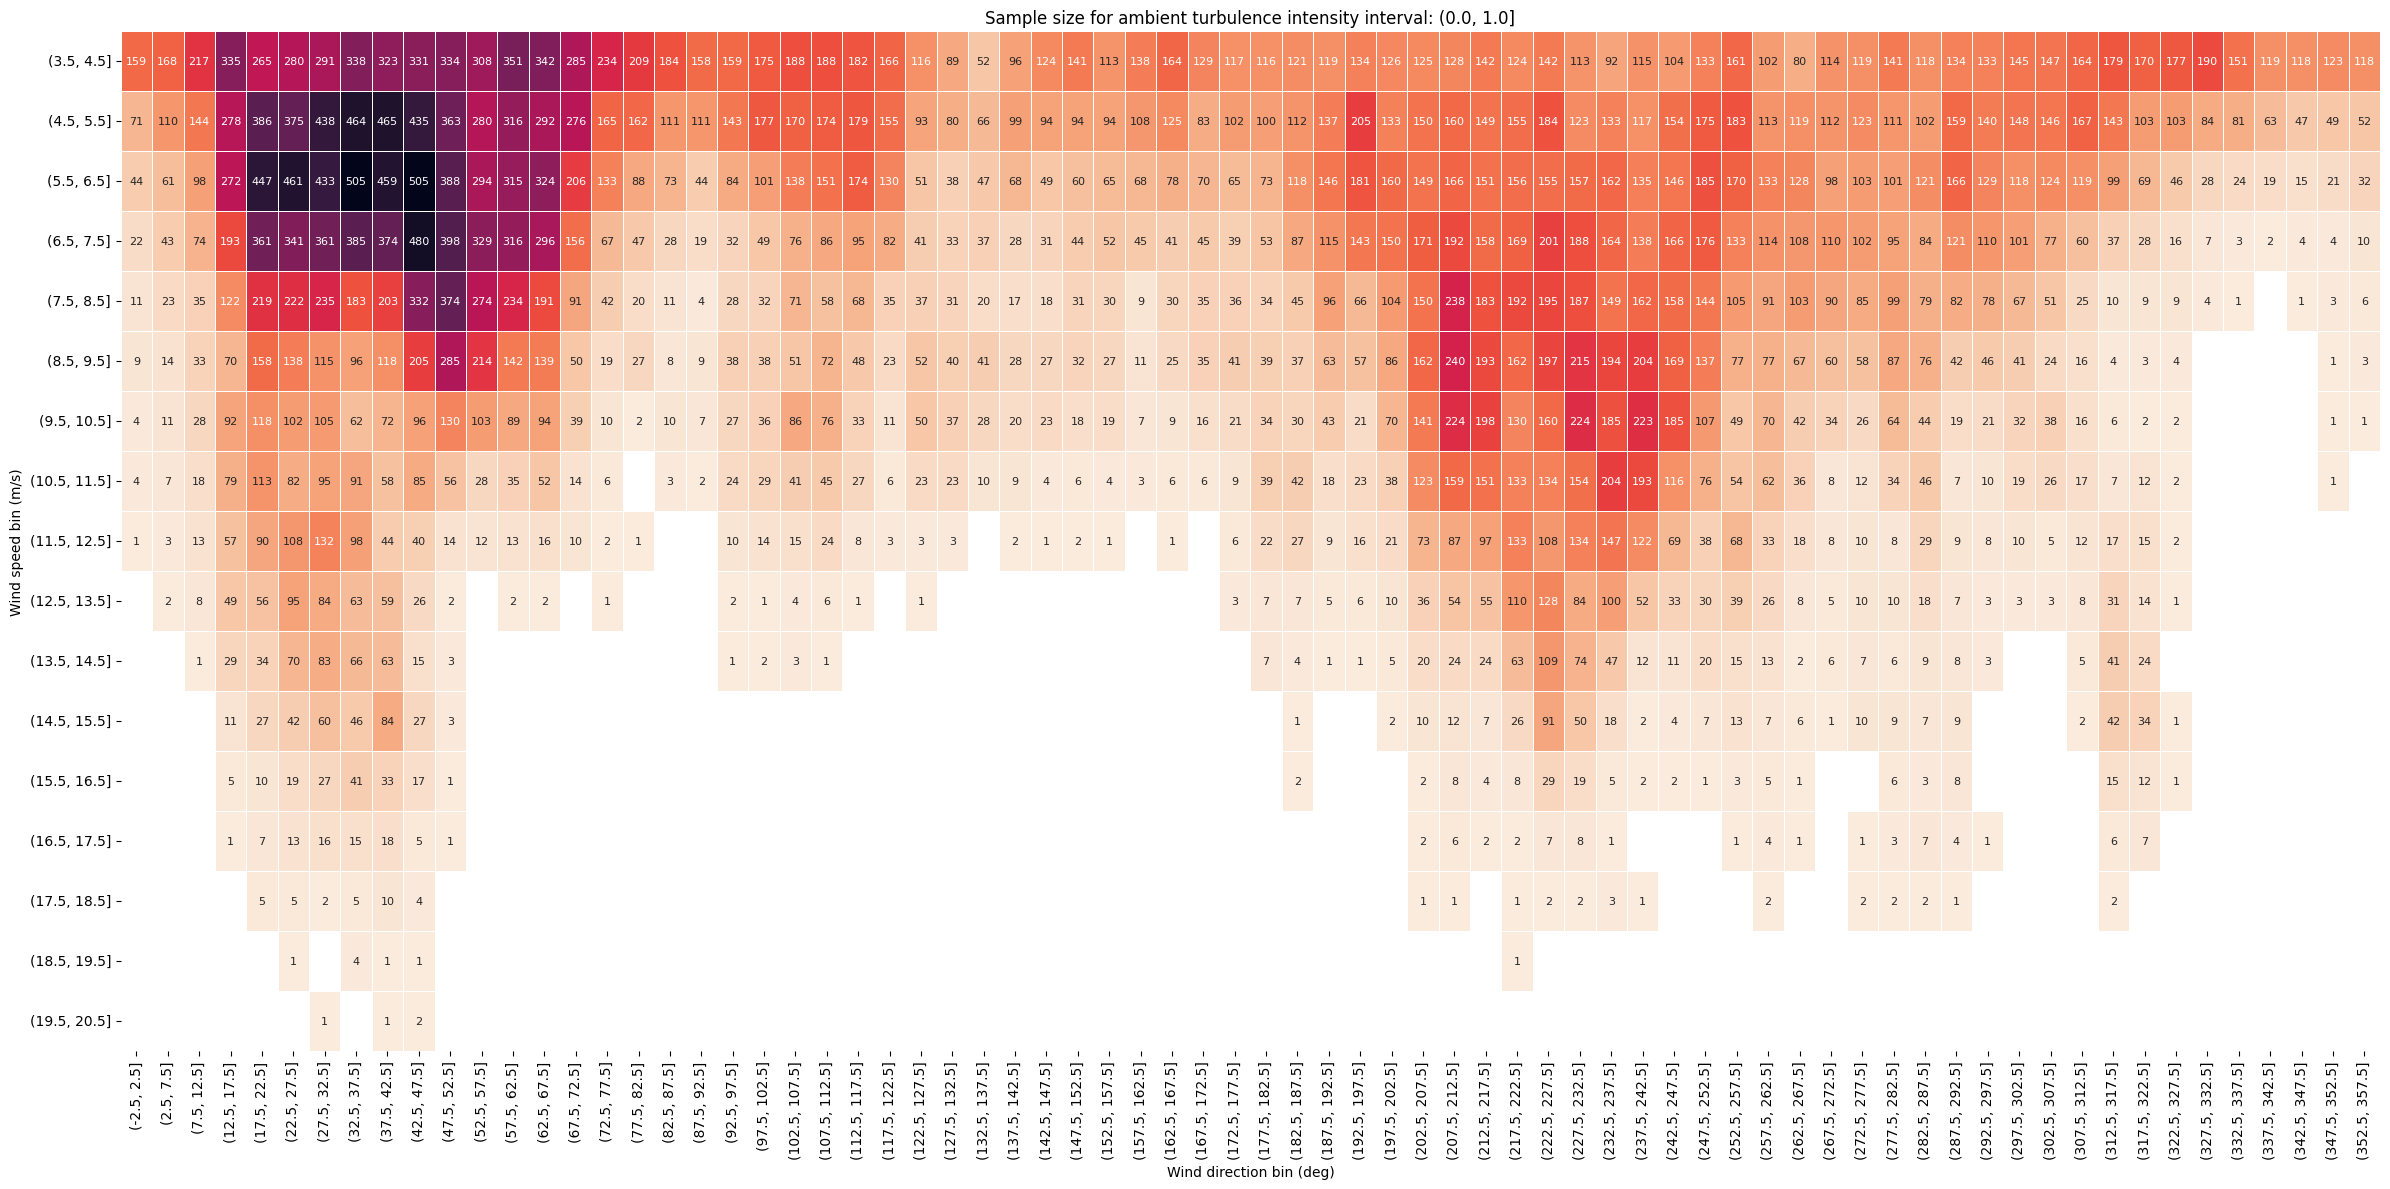

In [24]:
########################################################################################################################################
## Option for validation 2: we re-map the LES timeseries onto the SCADA ambient wind directions and wind speeds. This ensures the     ##
## ambient conditions are identical between the two datasets. We do this by turning the LES simulation into a steady-state table      ##
## of solutions, basically identical to a FLORIS solutions table.                                                                     ##
########################################################################################################################################

# # We start with the original timeseries, mapped onto the same time vector as the SCADA
df_les = df_les_raw_resampled.copy()

# Load the timeseries dataframe into the class
from flasc.data_processing.timeseries_to_grid_solutions import ConvertTimeseriesToSolutionGrid
g = ConvertTimeseriesToSolutionGrid(df_timeseries=df_les)

# Bin the LES data by wind directions and wind speeds (for now: not by TI)
df_binned = g.bin_timeseries(
    wd_step=5.0,
    ws_array=np.arange(3.5, np.ceil(df_fm_approx["ws"].max()) + 0.01, 1.0),
    ti_array=[0.0, 1.0],  # Pour everything into a single TI bin
    circular_cols=None,
    plot=True,
    verbose=True
)

# Convert the binned data into the right formatting matching those of df_fm_approx
df_les_steadystate_table = g.convert_binned_dataframe_to_df_fi_approx(N_min=3)  # At least 3 valid samples

# Use this steady-state table to produce a new timeseries with identical inflow as SCADA
df_les_timeseries_inflowremapped = ftools.interpolate_floris_from_df_approx(
    df=df_scada, df_approx=df_les_steadystate_table, method="linear", verbose=True
)

# Perform comparison using this inflow-remapped LES dataframe
table_absolute_aep_dict, table_wakeloss_aep_dict = compare_absolute_aep_and_relative_wake_loss(df_scada, df_les_timeseries_inflowremapped)

In [14]:
# df_scada["time"].diff().unique()
# from flasc.data_processing import time_operations as tops
# new_time_array = pd.date_range(start=df_scada.iloc[0]["time"], end=df_scada.iloc[-1]["time"], freq="600s")
# print(new_time_array)
# df_res = tops.df_resample_by_interpolation(
#     df=df_scada[["time", "wd", "ws", "ti"]],
#     time_array=new_time_array,
#     circular_cols=["wd"],
#     interp_method="linear",
#     verbose=True,
# )
# print(df_res)


In [15]:
# # Set pow_ref in FLORIS results as before
# for df_fm in df_fm_list:
#     df_fm = dfm.set_pow_ref_by_upstream_turbines(df_fm, df_upstream, exclude_turbs=[4])

In [16]:
# # Calculate and plot energy ratios
# a_in = AnalysisInput(
#     df_fm_list + [df_scada], ["FLORIS: " + wm for wm in wake_models] + ["SCADA data"]
# )

In [17]:
# N = 20
# print("Calculating energy ratios with bootstrapping (N={}).".format(N))
# print("This may take a couple seconds...")
# np.random.seed(0)
# er_out = er.compute_energy_ratio(
#     a_in,
#     test_turbines=[4],
#     use_predefined_ref=True,
#     use_predefined_wd=True,
#     use_predefined_ws=True,
#     wd_step=2.0,
#     wd_bin_overlap_radius=0.0,
#     ws_min=6.0,
#     ws_max=12.0,
#     N=N,
#     percentiles=[5.0, 95.0],
# )
# ax = er_out.plot_energy_ratios(overlay_frequency=True)
# ax[0].set_title("Energy Ratios for Turbine 004")

As shown in the plot above, overall there is good agreement between the SCADA-based energy ratio curve and the energy ratio predictions based on FLORIS results. However, because of relatively little data for many wind directions, the SCADA-based energy ratios are noisy and can deviate from the expected value of 1 when Turbine 004 is unwaked.

# Step 4: Rerun the energy ratio calculation with a different wind speed/wind direction distribution

As an example, we'll create a distribution with uniform frequency across 
all wind speds of interest and concentrated in the direction where SMV6 wakes SMV5.

Can also be used to evaluate the energy ratios under long-term site conditions.

In [18]:
# ws = np.tile(np.arange(6.5, 12.0, 1.0), 180)
# wd = np.repeat(np.arange(1.0, 360.0, 2.0), 6)

# freq = np.ones_like(ws)
# # Increase frequency value in steering wind directions
# start_idx = np.where(wd == 169)[0][0]
# end_idx = np.where(wd == 231)[0][0]
# freq[start_idx:end_idx] = 5
# freq = 10 * freq

# df_freq = pd.DataFrame({"ws": ws, "wd": wd, "freq_val": freq})

# N = 20
# print("Calculating energy ratios with bootstrapping (N={}).".format(N))
# print("This may take a couple seconds...")
# np.random.seed(0)
# er_out = er.compute_energy_ratio(
#     a_in,
#     test_turbines=[4],
#     use_predefined_ref=True,
#     use_predefined_wd=True,
#     use_predefined_ws=True,
#     wd_step=2.0,
#     wd_bin_overlap_radius=0.0,
#     ws_min=6.0,
#     ws_max=12.0,
#     df_freq=df_freq,
#     N=N,
#     percentiles=[5.0, 95.0],
# )
# ax = er_out.plot_energy_ratios(overlay_frequency=True)
# ax[0].set_title("Energy Ratios for Turbine 004")